# Bitcoin Market Sentiment vs. Hyperliquid Trader Performance
### PrimeTrade.ai Data Science Assignment

This notebook explores the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance on Hyperliquid, using ~211K trade records from 32 accounts.

**Structure**
1. Load & clean data
2. Merge on date
3. Performance by sentiment regime
4. Time-series relationship
5. Risk behavior (profit factor, direction bias, tail events)
6. Account & market composition
7. Key insights & strategy recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

## 1. Load & Clean Data

In [2]:
tr = pd.read_csv('hyperliquid_trader_data_csv.csv')
fg = pd.read_csv('fear_greed_index_csv.csv')

print("Trader data:", tr.shape)
print("Sentiment data:", fg.shape)
tr.head()

Trader data: (211224, 16)
Sentiment data: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
# Parse dates
tr['date'] = pd.to_datetime(tr['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
fg['date'] = pd.to_datetime(fg['date']).dt.date

print("Trader date range:", tr['date'].min(), "-", tr['date'].max())
print("Sentiment date range:", fg['date'].min(), "-", fg['date'].max())
print("Unique accounts:", tr['Account'].nunique())
print("Unique coins:", tr['Coin'].nunique())
print("\nNull check (trader data):")
print(tr.isnull().sum())

Trader date range: 2023-05-01 - 2025-05-01
Sentiment date range: 2018-02-01 - 2025-05-02
Unique accounts: 32
Unique coins: 246

Null check (trader data):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64


## 2. Merge Datasets on Date

In [5]:
df = tr.merge(fg[['date', 'value', 'classification']], on='date', how='left')

missing = df['classification'].isnull().sum()
print(f"Trades with no matching sentiment record: {missing} / {len(df)}")

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = ['#7f1d1d', '#dc2626', '#6b7280', '#16a34a', '#14532d']

df.head()

Trades with no matching sentiment record: 6 / 211224


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


## 3. Performance by Sentiment Regime

About half of all trade rows have `Closed PnL == 0` — these are position-opening trades (Open Long / Open Short), not realized outcomes. We separate "all trades" (volume/activity view) from "realized trades" (PnL != 0, the performance view).

In [6]:
zero_share = (df['Closed PnL'] == 0).mean() * 100
print(f"Share of trades with zero Closed PnL (position opens): {zero_share:.1f}%")

closed = df[df['Closed PnL'] != 0].copy()

perf = closed.groupby('classification').agg(
    realized_trades=('Closed PnL', 'count'),
    avg_pnl=('Closed PnL', 'mean'),
    median_pnl=('Closed PnL', 'median'),
    avg_size_usd=('Size USD', 'mean'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100),
    avg_win=('Closed PnL', lambda x: x[x > 0].mean()),
    avg_loss=('Closed PnL', lambda x: x[x < 0].mean()),
).reindex(order)

perf['profit_factor'] = (perf['avg_win'] * perf['win_rate']/100) / abs(perf['avg_loss'] * (1 - perf['win_rate']/100))
perf.round(2)

Share of trades with zero Closed PnL (position opens): 50.6%


,realized_trades,avg_pnl,median_pnl,avg_size_usd,win_rate,avg_win,avg_loss,profit_factor
classification,,,,,,,,
Extreme Fear,10406,71.03,6.39,5467.57,76.22,173.42,-257.10,2.16
Fear,29808,112.63,6.35,8041.14,87.29,151.84,-156.66,6.66
Neutral,18159,71.20,4.58,5556.44,82.39,112.44,-121.73,4.32
Greed,25176,85.40,4.93,5438.67,76.89,165.76,-181.97,3.03
Extreme Greed,20853,130.21,8.53,2779.56,89.17,160.59,-119.92,11.02


In [7]:
full_grp = df.groupby('classification').agg(
    trades=('Closed PnL', 'count'),
    total_pnl=('Closed PnL', 'sum'),
    total_volume=('Size USD', 'sum'),
).reindex(order)
full_grp.round(2)

,trades,total_pnl,total_volume
classification,,,
Extreme Fear,21400,739110.25,1.144843e+08
Fear,61837,3357155.44,4.833248e+08
Neutral,37686,1292920.68,1.802421e+08
Greed,50303,2150129.27,2.885825e+08
Extreme Greed,39992,2715171.31,1.244652e+08


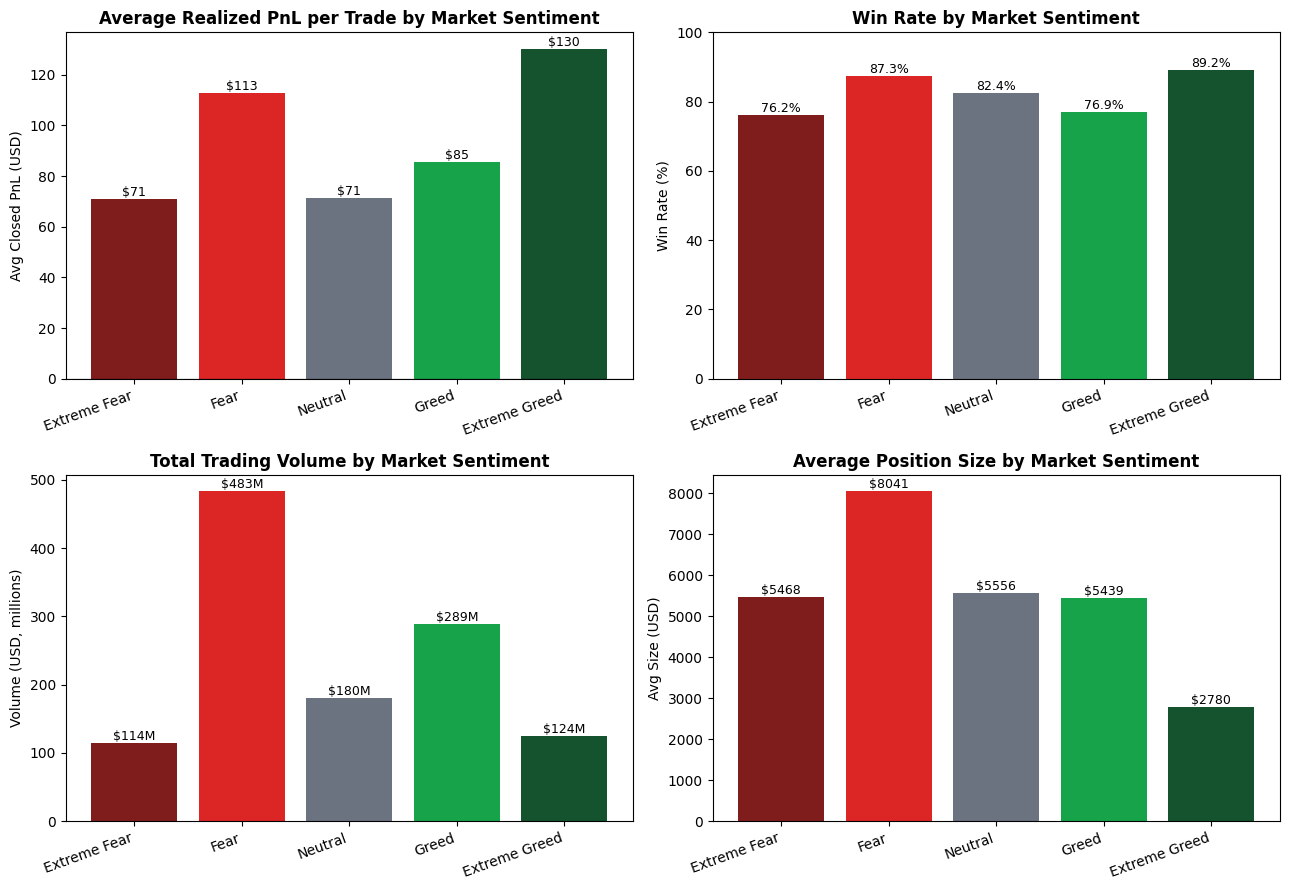

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0,0]
bars = ax.bar(order, perf['avg_pnl'], color=colors)
ax.set_title('Average Realized PnL per Trade by Market Sentiment', fontweight='bold')
ax.set_ylabel('Avg Closed PnL (USD)')
ax.axhline(0, color='black', linewidth=0.8)
for b, v in zip(bars, perf['avg_pnl']):
    ax.text(b.get_x()+b.get_width()/2, v, f'${v:.0f}', ha='center', va='bottom' if v>0 else 'top', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[0,1]
bars = ax.bar(order, perf['win_rate'], color=colors)
ax.set_title('Win Rate by Market Sentiment', fontweight='bold')
ax.set_ylabel('Win Rate (%)'); ax.set_ylim(0,100)
for b, v in zip(bars, perf['win_rate']):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[1,0]
bars = ax.bar(order, full_grp['total_volume']/1e6, color=colors)
ax.set_title('Total Trading Volume by Market Sentiment', fontweight='bold')
ax.set_ylabel('Volume (USD, millions)')
for b, v in zip(bars, full_grp['total_volume']/1e6):
    ax.text(b.get_x()+b.get_width()/2, v, f'${v:.0f}M', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[1,1]
bars = ax.bar(order, perf['avg_size_usd'], color=colors)
ax.set_title('Average Position Size by Market Sentiment', fontweight='bold')
ax.set_ylabel('Avg Size (USD)')
for b, v in zip(bars, perf['avg_size_usd']):
    ax.text(b.get_x()+b.get_width()/2, v, f'${v:.0f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

**Observation:** the relationship is non-linear — a "W-shape". Extreme Greed (89.2% win rate) and Fear (87.3%) are the best-performing regimes; Extreme Fear (76.2%) and plain Greed (76.9%) are the weakest.

## 4. Time-Series Relationship: Sentiment vs Daily PnL

In [9]:
daily = df.groupby('date').agg(
    sentiment_value=('value', 'first'),
    daily_pnl=('Closed PnL', 'sum'),
    daily_volume=('Size USD', 'sum'),
    daily_trades=('Closed PnL', 'count'),
    active_accounts=('Account', 'nunique'),
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

corr = daily[['sentiment_value','daily_pnl','daily_volume','daily_trades','active_accounts']].corr()
print("Correlation with sentiment value:")
print(corr['sentiment_value'].round(3))

Correlation with sentiment value:
sentiment_value    1.000
daily_pnl         -0.083
daily_volume      -0.264
daily_trades      -0.245
active_accounts   -0.278
Name: sentiment_value, dtype: float64


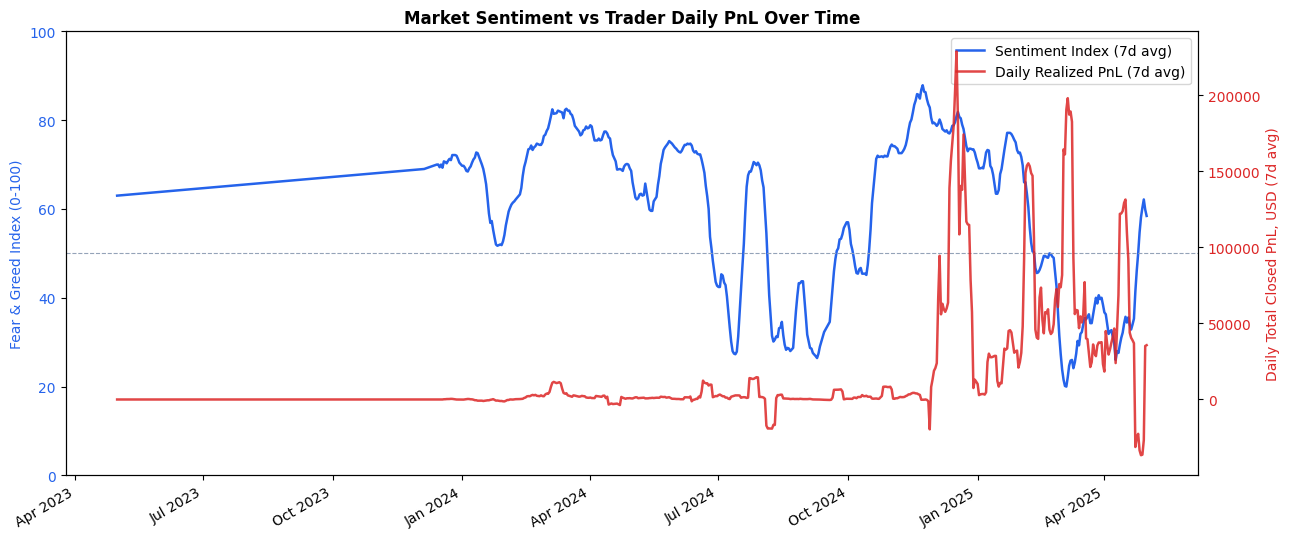

In [10]:
daily['pnl_7d'] = daily['daily_pnl'].rolling(7, min_periods=1).mean()
daily['sent_7d'] = daily['sentiment_value'].rolling(7, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.plot(daily['date'], daily['sent_7d'], color='#2563eb', linewidth=1.8, label='Sentiment Index (7d avg)')
ax1.set_ylabel('Fear & Greed Index (0-100)', color='#2563eb')
ax1.tick_params(axis='y', labelcolor='#2563eb')
ax1.axhline(50, color='#94a3b8', linestyle='--', linewidth=0.8)
ax1.set_ylim(0, 100)

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['pnl_7d'], color='#dc2626', linewidth=1.8, alpha=0.85, label='Daily Realized PnL (7d avg)')
ax2.set_ylabel('Daily Total Closed PnL, USD (7d avg)', color='#dc2626')
ax2.tick_params(axis='y', labelcolor='#dc2626')

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()
plt.title('Market Sentiment vs Trader Daily PnL Over Time', fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')
plt.tight_layout()
plt.show()

**Observation:** trade count, volume, and active-account participation all rise as sentiment falls toward Fear — traders are *more* active in fearful markets, not less.

## 5. Risk Behavior: Profit Factor, Direction Bias & Tail Events

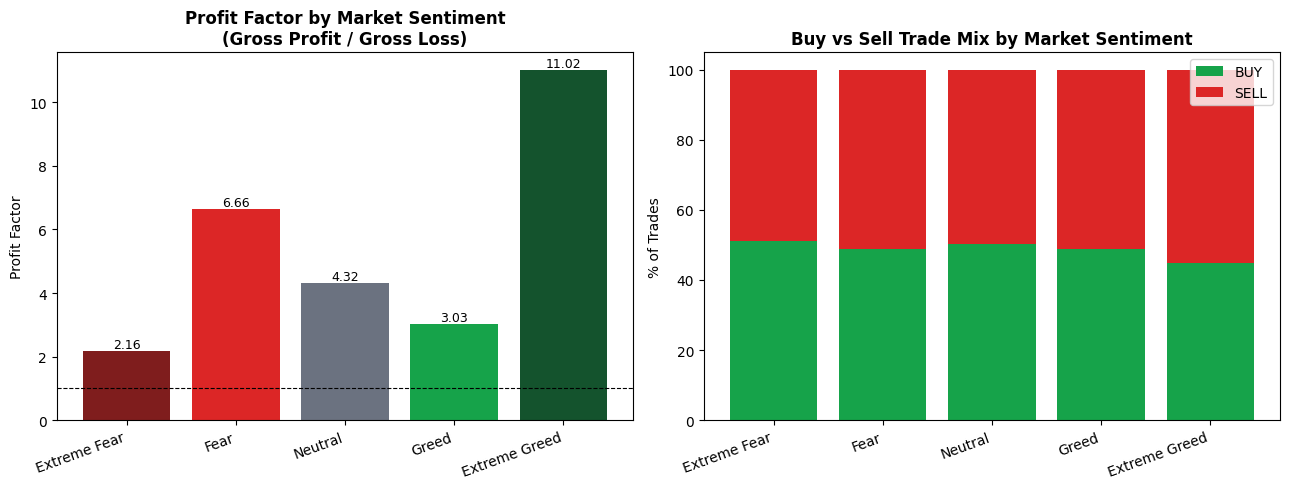

In [11]:
def profit_factor(x):
    wins = x[x > 0].sum()
    losses = abs(x[x < 0].sum())
    return wins / losses if losses > 0 else np.nan

pf = closed.groupby('classification')['Closed PnL'].apply(profit_factor).reindex(order)

side_mix = df.groupby('classification')['Side'].value_counts(normalize=True).unstack().reindex(order) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(order, pf, color=colors)
ax.axhline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Profit Factor by Market Sentiment\n(Gross Profit / Gross Loss)', fontweight='bold')
ax.set_ylabel('Profit Factor')
for b, v in zip(bars, pf):
    ax.text(b.get_x()+b.get_width()/2, v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

ax = axes[1]
bottom = np.zeros(len(order))
for side, color in [('BUY', '#16a34a'), ('SELL', '#dc2626')]:
    vals = side_mix[side].values
    ax.bar(order, vals, bottom=bottom, label=side, color=color)
    bottom += vals
ax.set_title('Buy vs Sell Trade Mix by Market Sentiment', fontweight='bold')
ax.set_ylabel('% of Trades')
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

In [12]:
# Liquidation & tail events
liq = df[df['Direction'].str.contains('Liquidat', case=False, na=False)]
print("Liquidation events:", len(liq))
display(liq[['date','classification','Account','Coin','Closed PnL','Size USD']])

print("\n10 largest single-trade losses:")
display(df.nsmallest(10, 'Closed PnL')[['date','classification','Account','Coin','Closed PnL','Size USD']])

print("\n10 largest single-trade gains:")
display(df.nlargest(10, 'Closed PnL')[['date','classification','Account','Coin','Closed PnL','Size USD']])

Liquidation events: 1


,date,classification,Account,Coin,Closed PnL,Size USD
118646,2025-04-23,Greed,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,-12752.91304,32910.88



10 largest single-trade losses:


,date,classification,Account,Coin,Closed PnL,Size USD
14682,2024-12-06,Greed,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,-117990.10410,814524.17
118582,2025-04-23,Greed,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,-83056.32000,214400.00
118498,2025-04-23,Greed,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,-41910.06915,115769.55
210767,2025-04-18,Fear,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,-35681.74723,237538.13
118487,2025-04-23,Greed,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,-34338.53409,95737.60
142241,2025-03-10,Extreme Fear,0x39cef799f8b69da1995852eea189df24eb5cae3c,@107,-31036.69194,80252.78
3737,2025-04-09,Extreme Fear,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,-29370.11980,373314.16
209185,2025-04-23,Greed,0x271b280974205ca63b716753467d5a371de622ab,BTC,-25818.75012,999998.56
203858,2025-02-06,Neutral,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,BERA,-24500.00000,107500.00
118613,2025-04-23,Greed,0x8170715b3b381dffb7062c0298972d4727a0a63b,TRUMP,-24080.11492,60000.97



10 largest single-trade gains:


,date,classification,Account,Coin,Closed PnL,Size USD
18045,2025-04-12,Fear,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,135329.09010,292870.12
17270,2025-02-28,Extreme Fear,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,115287.00000,685200.00
18043,2025-04-12,Fear,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,78682.72032,170279.86
210024,2025-01-08,Greed,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,74530.52371,921670.14
18024,2025-04-12,Fear,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,72377.74821,156635.06
16328,2025-02-04,Greed,0x083384f897ee0f19899168e3b1bec365f52a9012,SOL,71535.71674,301855.74
71354,2025-03-05,Extreme Fear,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,68959.00212,1120971.60
16377,2025-02-04,Greed,0x083384f897ee0f19899168e3b1bec365f52a9012,SOL,50379.05774,175555.89
49084,2025-02-09,Neutral,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,DOGE,48504.09555,60179.92
17075,2025-02-25,Fear,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,47883.62595,785654.97


**Observation:** the largest loss (-$117,990) and the dataset's only liquidation both occurred on **Greed** days — a single account lost >$184K across four TRUMP trades in one Greed day (2025-04-23). Several of the largest *gains*, by contrast, occurred during Fear/Extreme Fear — contrarian buying during fear paid off disproportionately.

## 6. Account & Market Composition

In [13]:
top_coins = df.groupby('Coin')['Size USD'].sum().sort_values(ascending=False).head(10)
print("Top 10 coins by volume:")
print(top_coins)

acct_pnl = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)
print("\nTop 5 accounts by total PnL:")
print(acct_pnl.head())
print("\nBottom 5 accounts by total PnL:")
print(acct_pnl.tail())

Top 10 coins by volume:
Coin
BTC         6.442321e+08
HYPE        1.419902e+08
SOL         1.250748e+08
ETH         1.182810e+08
@107        5.576086e+07
FARTCOIN    8.311390e+06
SUI         7.781168e+06
TRUMP       7.349347e+06
MELANIA     7.040710e+06
XRP         5.343211e+06
Name: Size USD, dtype: float64

Top 5 accounts by total PnL:
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
Name: Closed PnL, dtype: float64

Bottom 5 accounts by total PnL:
Account
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x8170715b3b381dffb7062c0298972d4727a0a63b 

In [14]:
acct_sent = df.groupby(['Account','classification'])['Closed PnL'].sum().unstack().reindex(columns=order)
print("Net-profitable accounts per regime:")
print((acct_sent > 0).sum())
print("\nTotal active accounts per regime:")
print(acct_sent.notna().sum())

Net-profitable accounts per regime:
classification
Extreme Fear     21
Fear             26
Neutral          21
Greed            27
Extreme Greed    26
dtype: int64

Total active accounts per regime:
classification
Extreme Fear     32
Fear             32
Neutral          31
Greed            31
Extreme Greed    30
dtype: int64


## 7. Key Insights & Strategy Recommendations

1. **Non-linear "W-shaped" performance**: traders do best in Fear and Extreme Greed, worst in Extreme Fear and plain Greed — sentiment extremes don't uniformly help or hurt; it depends which side and how extreme.
2. **Fear = highest activity, strong payoff**: trade count, volume and active accounts all rise as sentiment falls; Fear days combine the largest average position size, highest volume, and a strong 87% win rate — the data supports leaning in during Fear, not retreating.
3. **Extreme Fear is the true danger zone**: lowest profit factor (2.16) of all regimes — capitulation days call for smaller size, not maximum conviction.
4. **Greed (non-extreme) is the overconfidence risk**: hosts the single largest loss and the only liquidation in the dataset, despite a below-average win rate — position-size and leverage discipline matter most here.
5. **Extreme Greed traders were disciplined, not reckless**: smallest average size + highest win rate (89.2%) + highest profit factor (11.0) — a "ride the trend, take profit fast" pattern that's working and shouldn't be second-guessed just because sentiment is euphoric.
6. **BTC dominates flow** (54% of volume) with a long tail of altcoin speculation (246 coins traded); risk models should weight BTC-specific sentiment/volatility most heavily.

**Suggested actions**: (a) size normally-to-large in Fear, smaller in Extreme Fear; (b) apply the tightest leverage/position caps specifically during Greed (not Extreme Greed); (c) monitor spikes in trade/account activity as a leading proxy for fear regimes; (d) preserve current trend-following discipline into Extreme Greed rather than de-risking indiscriminately.
